In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
kidney_dataset = pd.read_csv("C:/Documants/mediscan/MediScan/Datasets/chronic_kidney_dieses_uci.csv")

kidney_dataset = kidney_dataset.iloc[2:]

kidney_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 2 to 201
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   bp (Diastolic)  200 non-null    str  
 1   bp limit        200 non-null    str  
 2   sg              200 non-null    str  
 3   al              200 non-null    str  
 4   class           200 non-null    str  
 5   rbc             200 non-null    str  
 6   su              200 non-null    str  
 7   pc              200 non-null    str  
 8   pcc             200 non-null    str  
 9   ba              200 non-null    str  
 10  bgr             200 non-null    str  
 11  bu              200 non-null    str  
 12  sod             200 non-null    str  
 13  sc              200 non-null    str  
 14  pot             200 non-null    str  
 15  hemo            200 non-null    str  
 16  pcv             200 non-null    str  
 17  rbcc            200 non-null    str  
 18  wbcc            200 non-null    str  
 19

kidney_dataset.head()

In [3]:
kidney_dataset.isna().sum()

bp (Diastolic)    0
bp limit          0
sg                0
al                0
class             0
rbc               0
su                0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sod               0
sc                0
pot               0
hemo              0
pcv               0
rbcc              0
wbcc              0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
grf               0
stage             0
affected          0
age               0
dtype: int64

As there is no null values there is nothing to remove. Now checking for duplicate values.

In [4]:
kidney_dataset.duplicated().sum()

np.int64(0)

There is now Duplicate value as well.

In [5]:
for col in kidney_dataset.columns:
    # check if column has any string values
    if kidney_dataset[col].apply(lambda x: isinstance(x, str)).any():
        mask = kidney_dataset[col] != kidney_dataset[col].str.strip()
        
        if mask.any():
            print(f"Column '{col}' has leading/trailing spaces")

Column 'grf' has leading/trailing spaces


As column grf has leading/trailing spaces we will remove it.

In [6]:
kidney_dataset['grf'] = kidney_dataset['grf'].astype("string").str.strip()


In [7]:
for col in kidney_dataset.select_dtypes(include=["object", "string"]).columns:
    print("\n", col)
    print(kidney_dataset[col].apply(lambda x: str(x).strip()).unique())


 bp (Diastolic)
<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

 bp limit
<ArrowStringArray>
['0', '1', '2']
Length: 3, dtype: str

 sg
<ArrowStringArray>
['1.019 - 1.021', '1.009 - 1.011', '1.015 - 1.017', '≥ 1.023', '< 1.007']
Length: 5, dtype: str

 al
<ArrowStringArray>
['1 - 1', '< 0', '≥ 4', '3 - 3', '2 - 2']
Length: 5, dtype: str

 class
<ArrowStringArray>
['ckd', 'notckd']
Length: 2, dtype: str

 rbc
<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

 su
<ArrowStringArray>
['< 0', '4 - 4', '2 - 2', '3 - 4', '1 - 2', '≥ 4']
Length: 6, dtype: str

 pc
<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

 pcc
<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

 ba
<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

 bgr
<ArrowStringArray>
[    '< 112', '112 - 154', '154 - 196', '406 - 448', '238 - 280', '196 - 238',
     '≥ 448', '280 - 322', '364 - 406', '322 - 364']
Length: 10, dtype: str

 bu
<ArrowStringArray>
[       '< 48.1',   '48.1 - 86.2', '200.5 - 238.6', '124.

as all the datset are in string , so first encoding them

In [8]:
from sklearn.preprocessing import LabelEncoder
df_encoded = kidney_dataset.copy()

label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le 


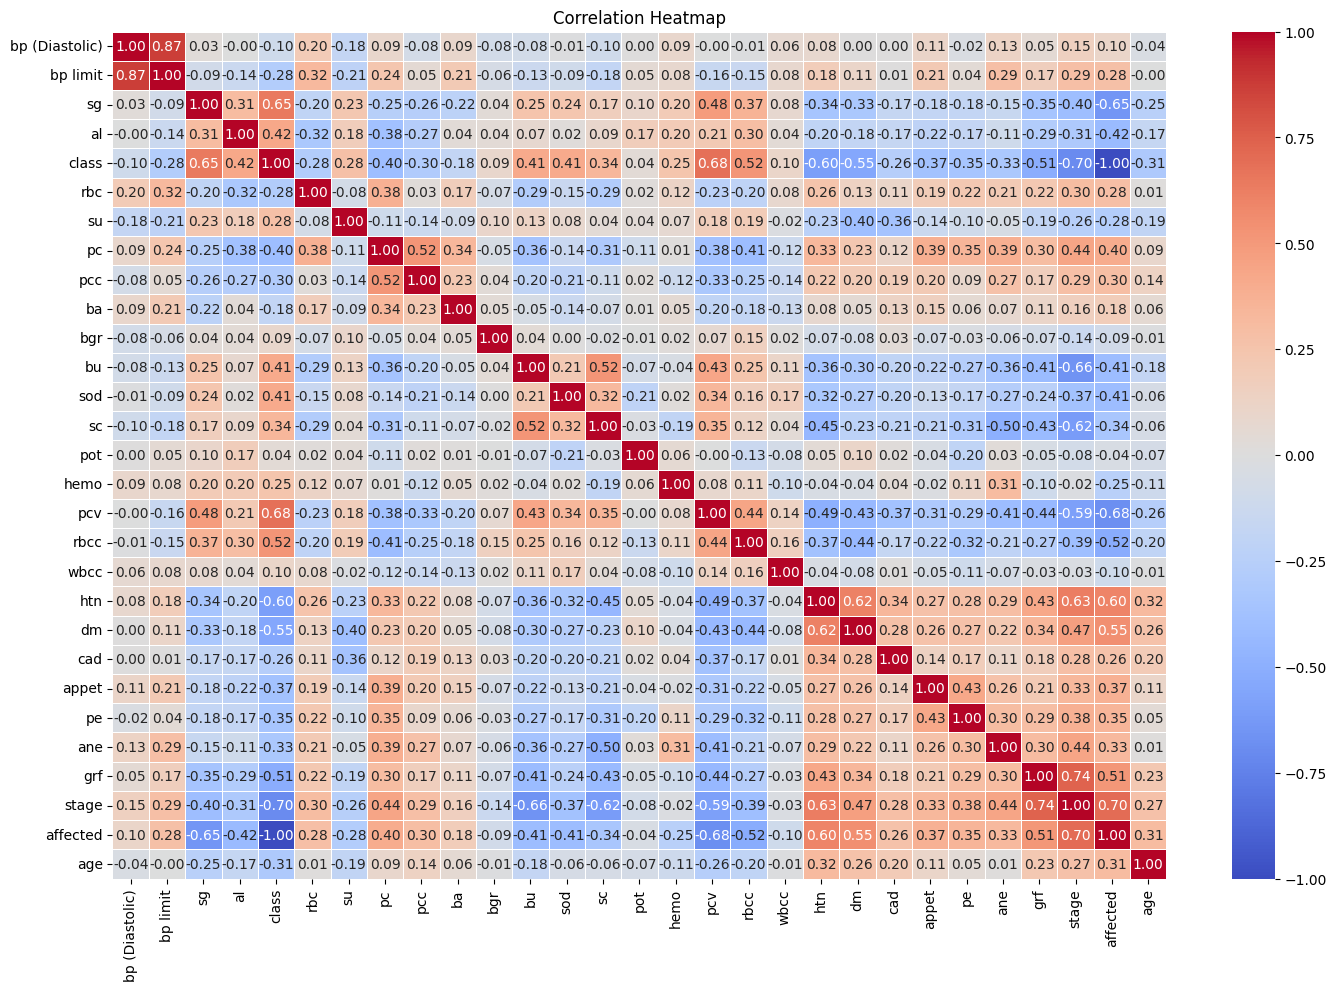

In [9]:
corr =df_encoded.corr(numeric_only=True)
plt.figure(figsize=(17,11))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

From the correlation matrix, I can see that specific gravity (sg) and pcv (packed cell volume) are strongly related with the target class, especially pcv which has a very high positive relationship. Also, hypertension (htn) and diabetes mellitus (dm) show strong negative correlation with the class, which means these conditions are closely linked with worse kidney outcomes. Overall, it looks like some features are clearly more important than others in separating the classes, so applying something like LDA before building the model would be a good idea, because it can reduce the dimensionality while keeping the class separation clear, making the model simpler and more effective.

In [10]:
from sklearn.model_selection import train_test_split
print("\n" + "="*60)
print( "SEPARATING FEATURES AND TARGET")
print("="*60)
 
X = df_encoded.drop(columns=['class', 'stage', 'affected'])
 
y = df_encoded['class']
 
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

print("\n" + "="*60)
print("STEP 3: SPLITTING DATA (80% TRAIN, 20% TEST)")
print("="*60)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,      
    stratify=y            
)
 
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training class distribution:")
print(f"  Class 0: {sum(y_train == 0)} samples")
print(f"  Class 1: {sum(y_train == 1)} samples")


SEPARATING FEATURES AND TARGET
Features (X) shape: (200, 26)
Target (y) shape: (200,)
Number of features: 26

STEP 3: SPLITTING DATA (80% TRAIN, 20% TEST)
Training set size: 160 samples
Testing set size: 40 samples
Training class distribution:
  Class 0: 102 samples
  Class 1: 58 samples


Now scalling the datset for LDA forward

In [11]:
from sklearn.preprocessing import StandardScaler
print("\n" + "="*60)
print("STEP 4: STANDARDIZING FEATURES")
print("="*60)
 
scaler = StandardScaler()
 
X_train_scaled = scaler.fit_transform(X_train)
 
X_test_scaled = scaler.transform(X_test)
 
print("Data standardized")
print(f"  Mean of first feature (before): {X_train.iloc[:, 0].mean():.3f}")
print(f"  Mean of first feature (after): {X_train_scaled[:, 0].mean():.3f}")
print(f"  Std of first feature (before): {X_train.iloc[:, 0].std():.3f}")
print(f"  Std of first feature (after): {X_train_scaled[:, 0].std():.3f}")



STEP 4: STANDARDIZING FEATURES
Data standardized
  Mean of first feature (before): 0.525
  Mean of first feature (after): -0.000
  Std of first feature (before): 0.501
  Std of first feature (after): 1.000


Now we can perform LDA

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
print("\n" + "="*60)
print("STEP 5: APPLYING LDA (Dimensionality Reduction)")
print("="*60)
 
# Create LDA object (reduce to 1 component for binary classification)
lda = LinearDiscriminantAnalysis(n_components=1, solver='eigen', shrinkage='auto')
 
# Fit LDA on training data
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
 
# Transform test data
X_test_lda = lda.transform(X_test_scaled)
 
print(f"LDA applied successfully")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Reduced features: {X_train_lda.shape[1]}")

 


STEP 5: APPLYING LDA (Dimensionality Reduction)
LDA applied successfully
Original features: 26
Reduced features: 1


We can visulize this LDA sepration by scatter plot

In [13]:
print("="*60)
print("DEBUGGING LDA VALUES")
print("="*60)

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_scaled min: {X_train_scaled.min()}")
print(f"X_train_scaled max: {X_train_scaled.max()}")
print(f"X_train_scaled mean: {X_train_scaled.mean()}")

print(f"\nX_train_lda shape: {X_train_lda.shape}")
print(f"X_train_lda min: {X_train_lda.min()}")
print(f"X_train_lda max: {X_train_lda.max()}")
print(f"X_train_lda mean: {X_train_lda.mean()}")

print(f"\nFirst 5 LDA values:")
print(X_train_lda[:5])

DEBUGGING LDA VALUES

X_train_scaled shape: (160, 26)
X_train_scaled min: -10.284855014915099
X_train_scaled max: 5.239454441560522
X_train_scaled mean: 3.3093186310942168e-18

X_train_lda shape: (160, 1)
X_train_lda min: -5.187189333483397
X_train_lda max: 4.160670486754892
X_train_lda mean: 1.9984014443252818e-16

First 5 LDA values:
[[ 1.49475305]
 [ 3.26075088]
 [ 2.25917707]
 [-3.24990147]
 [ 2.73195817]]


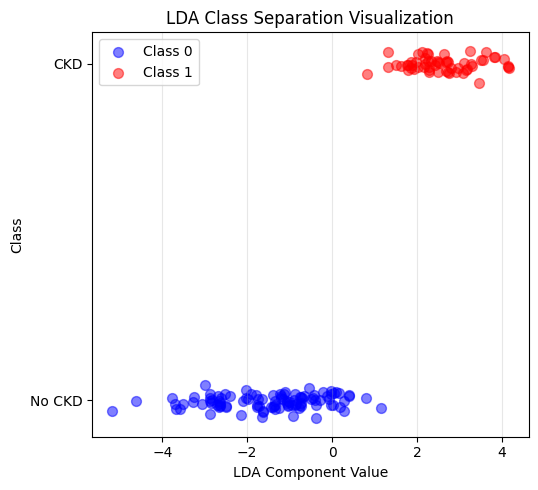

In [14]:

plt.figure(figsize=(10, 5))
 
plt.subplot(1, 2, 2)
plt.scatter(X_train_lda[y_train == 0], np.zeros(sum(y_train == 0)) + np.random.normal(0, 0.02, sum(y_train == 0)),
           alpha=0.5, s=50, label='Class 0', color='blue')
plt.scatter(X_train_lda[y_train == 1], np.ones(sum(y_train == 1)) + np.random.normal(0, 0.02, sum(y_train == 1)),
           alpha=0.5, s=50, label='Class 1', color='red')
plt.yticks([0, 1], ['No CKD', 'CKD'])
plt.xlabel('LDA Component Value')
plt.ylabel('Class')
plt.title('LDA Class Separation Visualization')
plt.legend()
plt.grid(alpha=0.3, axis='x')
 
plt.tight_layout()
plt.show()
 


Now traing Random forest model after applying LDA because LDA reduces the data and separates the classes better. This helps Random Forest focus on important patterns in the medical data while reducing noise and improving prediction performance.

In [15]:
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print(" TRAINING RANDOM FOREST MODEL")
print("="*60)
 

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
 
model.fit(X_train_lda, y_train)
 
print("Model trained successfully")
print(f"  Model type: Random Forest Classifier")
print(f"  Number of trees: 100")
print(f"  Max depth: 10")
 
y_pred = model.predict(X_test_lda)
 
y_pred_proba = model.predict_proba(X_test_lda)[:, 1]
 
print("Predictions made on test set")


 TRAINING RANDOM FOREST MODEL
Model trained successfully
  Model type: Random Forest Classifier
  Number of trees: 100
  Max depth: 10
Predictions made on test set


In [16]:
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,roc_auc_score, confusion_matrix, classification_report
import joblib

print("\n" + "-"*60)
print("OVERALL PERFORMANCE METRICS")
print("-"*60)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted"
)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")



------------------------------------------------------------
OVERALL PERFORMANCE METRICS
------------------------------------------------------------
Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)
F1-Score:  1.0000
ROC-AUC:   1.0000


In [17]:

# =========================================================
# 10-FOLD CROSS VALIDATION
# =========================================================

print("\n" + "="*60)
print("10-FOLD CROSS VALIDATION")
print("="*60)

from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation
cv_scores = cross_val_score(
    model,
    X_train_lda,
    y_train,
    cv=10,
    scoring='accuracy'
)

print("\n📊 ACCURACY FOR EACH FOLD:\n")

for fold, score in enumerate(cv_scores, 1):
    print(f"  Fold {fold:2d}: {score:.4f} ({score*100:.2f}%)")

# =========================================================
# CROSS VALIDATION SUMMARY STATISTICS
# =========================================================

print("\n" + "-"*60)
print("CROSS VALIDATION SUMMARY")
print("-"*60)

print(f"Mean Accuracy:     {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Std Deviation:     {cv_scores.std():.4f}")
print(f"Min Accuracy:      {cv_scores.min():.4f} ({cv_scores.min()*100:.2f}%)")
print(f"Max Accuracy:      {cv_scores.max():.4f} ({cv_scores.max()*100:.2f}%)")

# =========================================================
# COMPARISON: TEST SET vs CROSS VALIDATION
# =========================================================

print("\n" + "-"*60)
print("COMPARISON: TEST SET vs CROSS VALIDATION")
print("-"*60)

print(f"Test Set Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"CV Mean Accuracy:      {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Difference:            {abs(accuracy - cv_scores.mean()):.4f}")

if abs(accuracy - cv_scores.mean()) < 0.05:
    print(f"NO OVERFITTING - Model generalizes well!")
else:
    print(f"POSSIBLE OVERFITTING - Difference is significant")


10-FOLD CROSS VALIDATION

📊 ACCURACY FOR EACH FOLD:

  Fold  1: 1.0000 (100.00%)
  Fold  2: 1.0000 (100.00%)
  Fold  3: 0.8750 (87.50%)
  Fold  4: 1.0000 (100.00%)
  Fold  5: 0.9375 (93.75%)
  Fold  6: 1.0000 (100.00%)
  Fold  7: 1.0000 (100.00%)
  Fold  8: 1.0000 (100.00%)
  Fold  9: 1.0000 (100.00%)
  Fold 10: 1.0000 (100.00%)

------------------------------------------------------------
CROSS VALIDATION SUMMARY
------------------------------------------------------------
Mean Accuracy:     0.9812 (98.12%)
Std Deviation:     0.0400
Min Accuracy:      0.8750 (87.50%)
Max Accuracy:      1.0000 (100.00%)

------------------------------------------------------------
COMPARISON: TEST SET vs CROSS VALIDATION
------------------------------------------------------------
Test Set Accuracy:     1.0000 (100.00%)
CV Mean Accuracy:      0.9812 (98.12%)
Difference:            0.0188
NO OVERFITTING - Model generalizes well!
